# 🖌️ 30-Prompt Ink Wash Benchmark & CMMD Evaluation Notebook

This notebook evaluates the best fine-tuned LoRA checkpoints for each dataset size against the **Un-adapted Step 0 Baseline Model** across a fixed validation set of **30 prompts** categorized into 4 traditional Chinese ink wash painting themes:

1. **🏔️ Landscapes (山水)**: Misty mountains, pine trees, waterfalls, snow peaks, serene lakes (Prompts 1–8)
2. **🪶 Flora & Fauna (花鳥)**: Bamboo, soaring cranes, plum blossoms, lotus, galloping horses, orchids (Prompts 9–16)
3. **⛵ Minimalist Composition (意境/留白)**: Single boat, lone fisherman, wide white space, subtle mist (Prompts 17–23)
4. **🏯 Detailed Architecture (人物/亭台)**: Mountain pavilions, walking scholars, stone bridges, cloud pagodas (Prompts 24–30)

---

### 📊 Dual Evaluation Metrics
- **CLIPScore (Text-Image Alignment)**: Cosine similarity between prompt text embedding $\mathbf{v}_{text}$ and generated image embedding $\mathbf{v}_{img}$.
- **CMMD (CLIP Maximum Mean Discrepancy)**: Distance between the generated image distribution $X$ and reference ground-truth ink wash dataset images $Y$:
$$\text{MMD}^2(X, Y) = \frac{1}{M^2}\sum_{i,j} k(\mathbf{x}_i, \mathbf{x}_j) + \frac{1}{N^2}\sum_{i,j} k(\mathbf{y}_i, \mathbf{y}_j) - \frac{2}{MN}\sum_{i,j} k(\mathbf{x}_i, \mathbf{y}_j)$$

In [1]:
import os
import sys
import csv
import pandas as pd
import matplotlib.pyplot as plt
import torch
from pathlib import Path
from PIL import Image

def get_repository_root() -> Path:
    curr = Path.cwd().resolve()
    for parent in [curr] + list(curr.parents):
        if (parent / "README.md").is_file() or (parent / ".git").is_dir():
            return parent
    return curr

root_dir = get_repository_root()
output_root = root_dir / "outputs" / "benchmark_30prompts"

print(f"Repository Root: {root_dir}")
print(f"Benchmark Root: {output_root}")

Repository Root: C:\dev\efficient-pixart-sigma-lora
Benchmark Root: C:\dev\efficient-pixart-sigma-lora\outputs\benchmark_30prompts


## 1. 📊 Overall Model Summary (Avg CLIPScore & CMMD Distance)

In [2]:
summary_csv = output_root / "benchmark_summary.csv"
if summary_csv.is_file():
    df_summary = pd.read_csv(summary_csv)
    display(df_summary.sort_values("cmmd_score"))
else:
    print(f"Benchmark summary CSV not found at {summary_csv}. Evaluation task is running in background.")

,model_id,model_name,avg_clip_score,cmmd_score
3,plant209_best,Best plant209 (Step 4000),0.360187,0.001229
4,n260_best,Best n260 (Step 2000),0.353863,0.001445
2,n100_best,Best n100 (Step 1000),0.352484,0.001709
1,n50_best,Best n50 (Step 1000),0.349272,0.001762
0,baseline,Baseline Model (Step 0),0.348983,0.001900


## 2. 🎯 Category-Wise CLIPScore Breakdown

category,Architecture,Flora_Fauna,Landscapes,Minimalist
model_name,,,,
Baseline Model (Step 0),0.347930,0.350726,0.345765,0.351722
Best n100 (Step 1000),0.368983,0.352038,0.355979,0.332499
Best n260 (Step 2000),0.363432,0.352329,0.356894,0.344382
Best n50 (Step 1000),0.366132,0.349780,0.351181,0.329651
Best plant209 (Step 4000),0.368274,0.356617,0.363720,0.352143


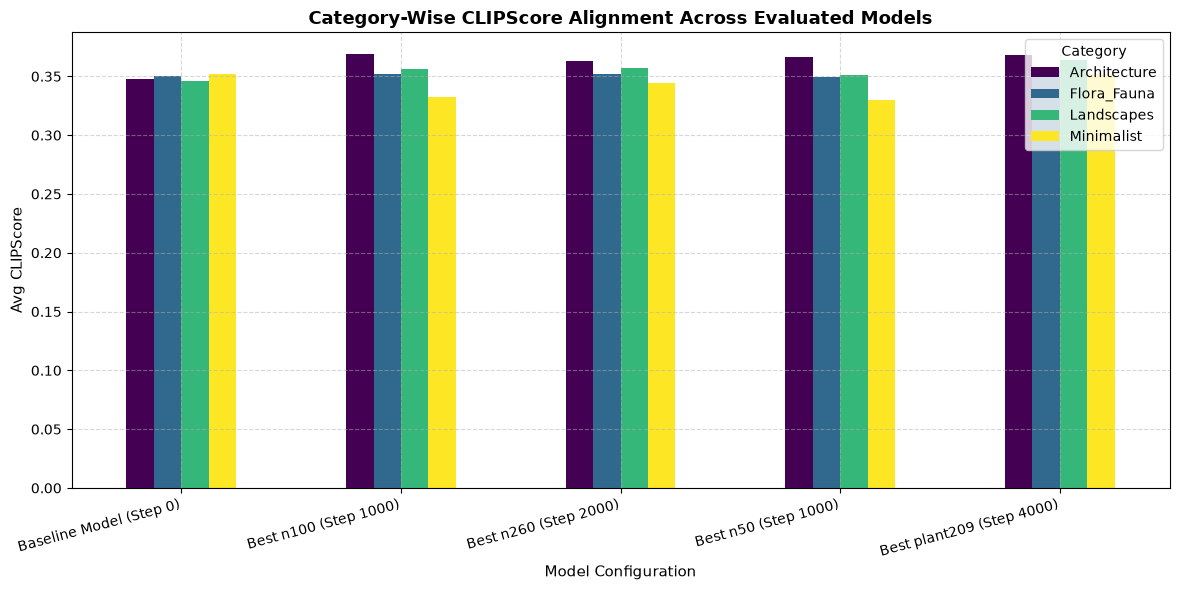

In [3]:
detail_csv = output_root / "benchmark_30prompts_detail.csv"
if detail_csv.is_file():
    df_detail = pd.read_csv(detail_csv)
    cat_pivot = df_detail.groupby(["model_name", "category"])["clip_score"].mean().unstack()
    display(cat_pivot)
    
    # Plot bar chart
    cat_pivot.plot(kind="bar", figsize=(12, 6), colormap="viridis")
    plt.title("Category-Wise CLIPScore Alignment Across Evaluated Models", fontsize=13, fontweight="bold")
    plt.ylabel("Avg CLIPScore", fontsize=11)
    plt.xlabel("Model Configuration", fontsize=11)
    plt.xticks(rotation=15, ha="right")
    plt.grid(True, linestyle="--", alpha=0.5)
    plt.legend(title="Category", fontsize=10)
    plt.tight_layout()
    plt.show()

## 3. 🖼️ Visual Comparison Grid Across Categories

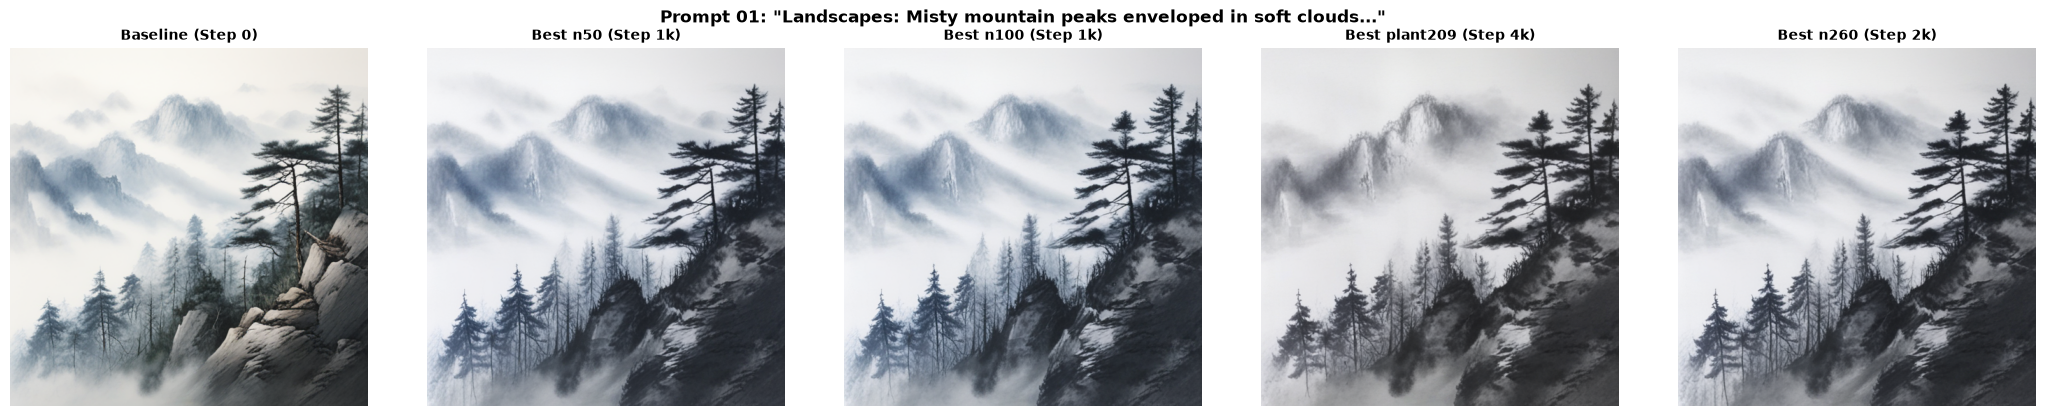

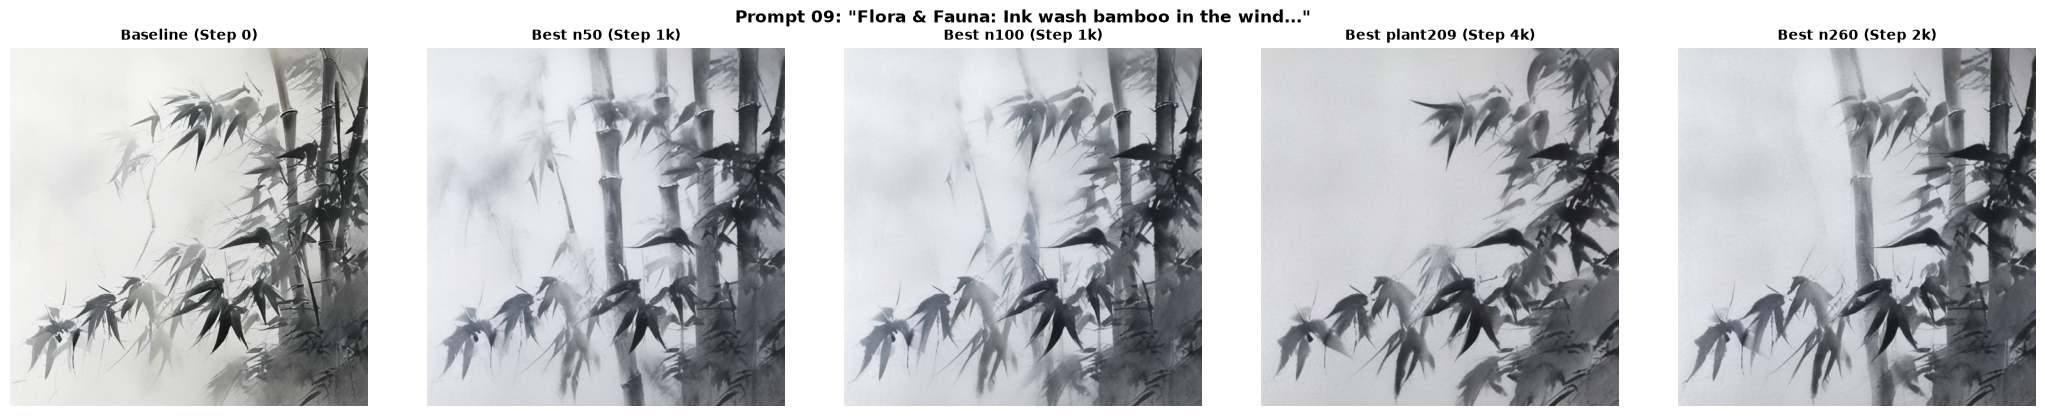

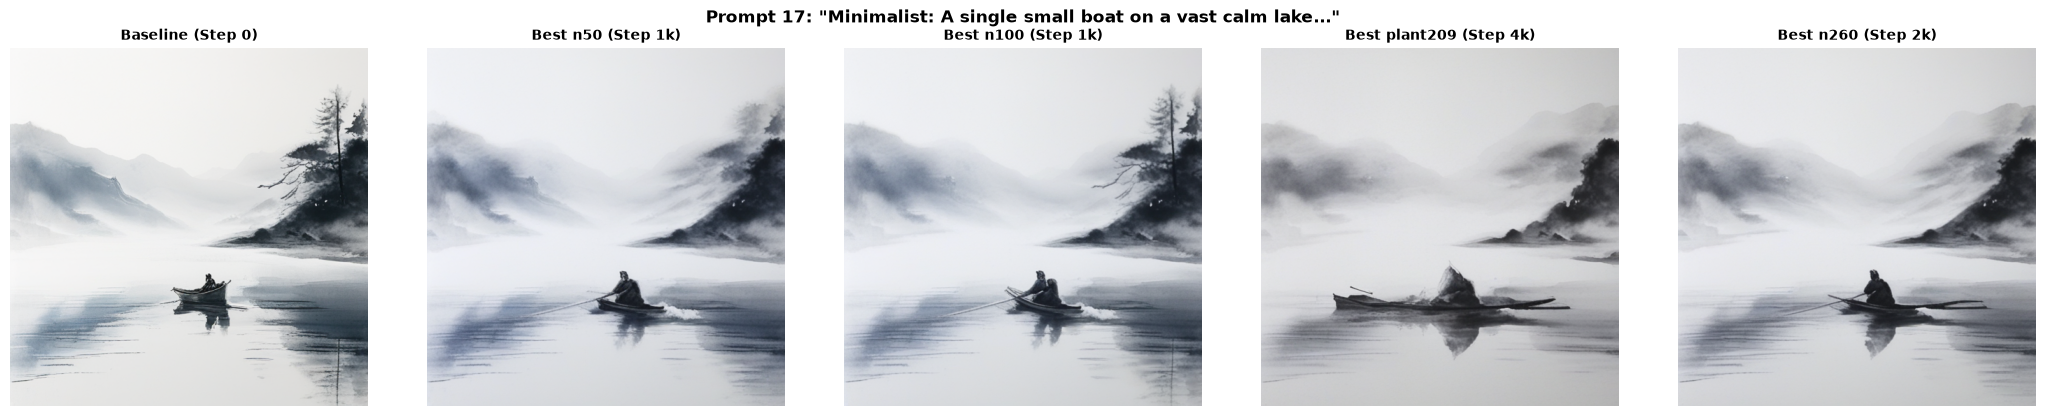

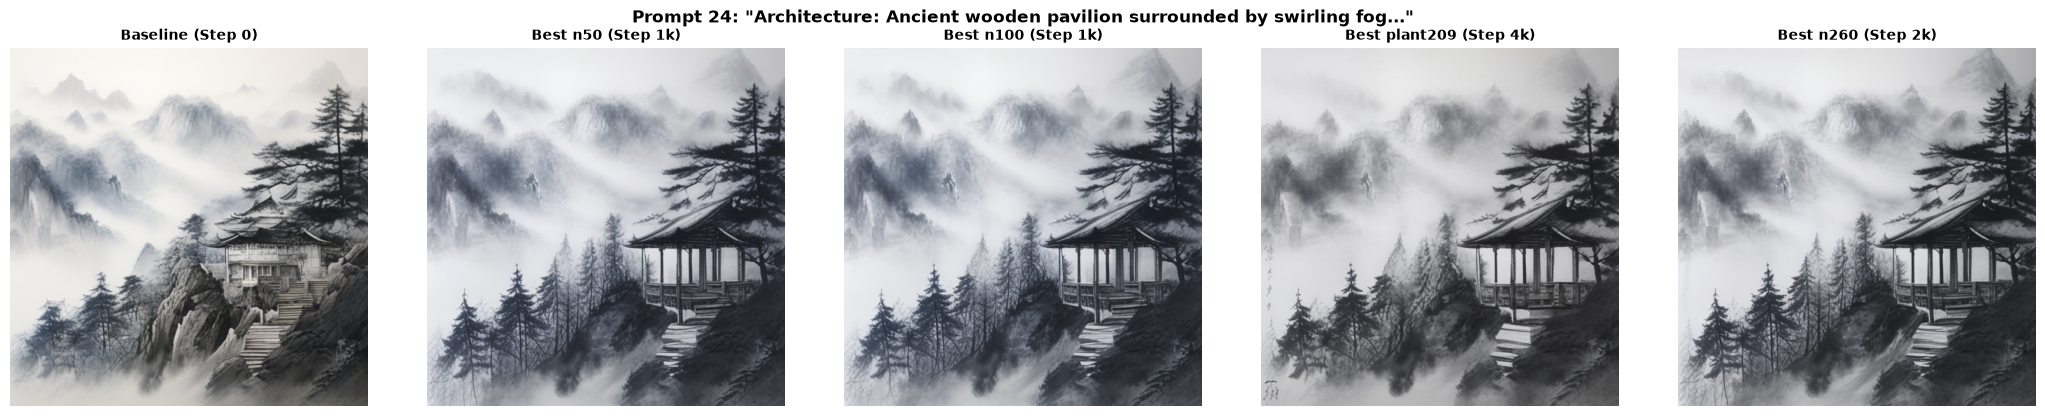

In [4]:
def render_category_comparison(prompt_id: int, prompt_desc: str):
    models = [
        ("baseline", "Baseline (Step 0)"),
        ("n50_best", "Best n50 (Step 1k)"),
        ("n100_best", "Best n100 (Step 1k)"),
        ("plant209_best", "Best plant209 (Step 4k)"),
        ("n260_best", "Best n260 (Step 2k)"),
    ]
    
    fig, axes = plt.subplots(1, len(models), figsize=(4.2 * len(models), 4.2))
    fig.suptitle(f"Prompt {prompt_id:02d}: \"{prompt_desc}\"", fontsize=12, fontweight="bold")
    
    for idx, (m_id, m_label) in enumerate(models):
        img_path = output_root / "generations" / m_id / f"prompt_{prompt_id:02d}.png"
        if img_path.is_file():
            img = Image.open(img_path)
            axes[idx].imshow(img)
            axes[idx].set_title(m_label, fontsize=10, fontweight="bold")
            axes[idx].axis("off")
        else:
            axes[idx].text(0.5, 0.5, f"{m_label}\n(Pending)", ha="center", va="center", fontsize=10)
            axes[idx].axis("off")
            
    plt.tight_layout()
    plt.show()

# Display sample prompts for each category
sample_prompts = [
    (1, "Landscapes: Misty mountain peaks enveloped in soft clouds..."),
    (9, "Flora & Fauna: Ink wash bamboo in the wind..."),
    (17, "Minimalist: A single small boat on a vast calm lake..."),
    (24, "Architecture: Ancient wooden pavilion surrounded by swirling fog..."),
]
for p_id, desc in sample_prompts:
    render_category_comparison(p_id, desc)